# **Heart Failure Prediction Model (Optimized using Hyper Parameters Tuning) using Random Forest**
For this heart failure prediction model project, I have utilized the Random Forest algorithm to develop a predictive model for heart disease. My work towards this development of heart failure prediction model focused on training the model on the processed dataset, optimizing its parameters, and evaluating its performance using standard classification metrics.

In [1]:
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

# **Preparing The Dataset**

In [2]:
columns = ["Age","Sex","ChestPainType", "RestingBP","Cholesterol","FastingBS","RestingECG","MaxHR","ExerciseAngina","Oldpeak","ST_Slope","HeartDisease"]

# This will load dataset directly from Kaggle
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "fedesoriano/heart-failure-prediction",
  "heart.csv",
)

print("Dataframe shape : ",df.shape)
df.head()

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Dataframe shape :  (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# **Cleaning The Dataset**

In [5]:
# Replace invalid zero values in 'Cholesterol' and 'RestingBP' with the median
# because zero is not physiologically possible and would skew the model.
df["Cholesterol"] = df["Cholesterol"].replace(0, df["Cholesterol"].median())
df["RestingBP"] = df["RestingBP"].replace(0, df["RestingBP"].median())

In [6]:
# Removing rows with missing values
df = df.dropna(subset=["Age","Sex","ChestPainType", "RestingBP","Cholesterol","FastingBS","RestingECG","MaxHR","ExerciseAngina","Oldpeak","ST_Slope","HeartDisease"])

# Encoding Categorical columns
cat_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_encoded = pd.get_dummies(df, columns=cat_columns, drop_first=False)

# Feature Engineering Block
df_encoded['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,40,55,70,100],
    labels=[0,1,2,3],
    include_lowest=True
)

df_encoded['Age_Group'] = df_encoded['Age_Group'].astype(float)
df_encoded['Age_Group'] = df_encoded['Age_Group'].fillna(0)  # Fixed

df_encoded['BP_Cholesterol'] = df['RestingBP'] * df['Cholesterol']
df_encoded['HR_Oldpeak'] = df['MaxHR'] * df['Oldpeak']
df_encoded['Chol_by_Age'] = df['Cholesterol'] / (df['Age'] + 1)
df_encoded['BP_by_Age'] = df['RestingBP'] / (df['Age'] + 1)

# Log transform - Fixed to handle zeros/negatives
df_encoded['Oldpeak'] = np.log1p(df_encoded['Oldpeak'].clip(lower=0))
df_encoded['Cholesterol'] = np.log1p(df_encoded['Cholesterol'].clip(lower=0))

# Replace infinite values with NaN
df_encoded = df_encoded.replace([np.inf, -np.inf], np.nan)

# Fill all NaN values
df_encoded = df_encoded.fillna(df_encoded.median(numeric_only=True))

print("Dataframe shape : ", df_encoded.shape)
print("Columns : ", df_encoded.columns)

Dataframe shape :  (918, 26)
Columns :  Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up', 'Age_Group', 'BP_Cholesterol',
       'HR_Oldpeak', 'Chol_by_Age', 'BP_by_Age'],
      dtype='object')


# **Class Distribution of the Dataset**

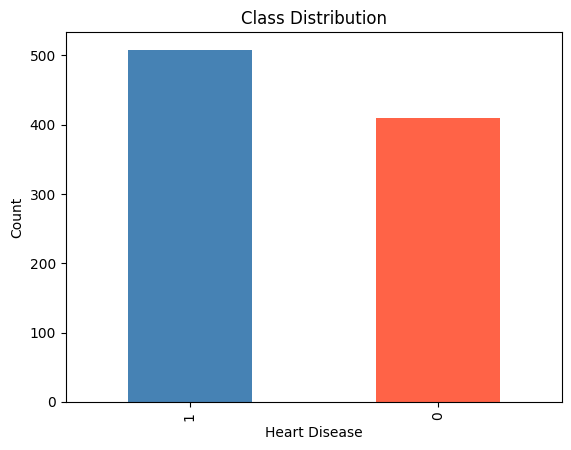

In [7]:
df["HeartDisease"].value_counts().plot(kind="bar", color=["steelblue","tomato"])
plt.title("Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

# **Applying SMOTE (Since The Dataset is Imbalanced)**

In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

In [9]:
X = df_encoded.drop("HeartDisease",axis=1)
y = df_encoded["HeartDisease"]

In [10]:
# Splitting the dataset before SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [12]:
print("Before SMOTE : ", Counter(y_train))
print("After SMOTE : ",Counter(y_train_resampled))

Before SMOTE :  Counter({1: 401, 0: 333})
After SMOTE :  Counter({0: 401, 1: 401})


# **Class Distribution After Applying SMOTE**

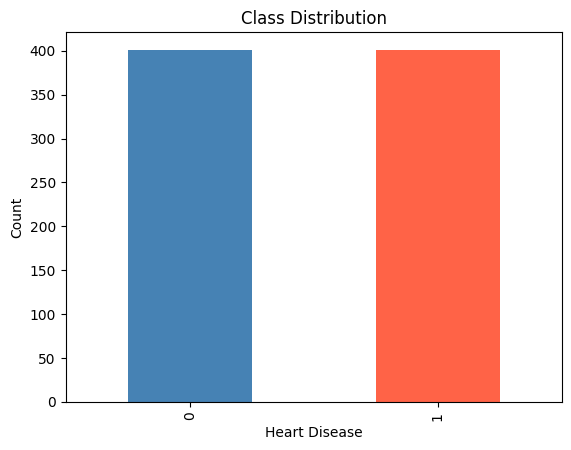

In [13]:
y_train_resampled.value_counts().plot(kind="bar", color=["steelblue","tomato"])
plt.title("Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

# **Model Creation and Applying RandomSearchCV for Optimizing Hyper Parameters**

In [19]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [20]:
param_dist = {
    'n_estimators': [10, 100, 200, 500, 1000, 1200],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2,4,6],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ["sqrt", "log2"],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_cv = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=param_dist,
    n_iter=100,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)

random_search_cv.fit(X_train, y_train)

best_params = random_search_cv.best_params_
print("Best parameters : ",best_params)

best_random_forest = random_search_cv.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters :  {'n_estimators': 10, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'criterion': 'entropy', 'class_weight': None, 'bootstrap': False}


In [21]:
best_random_forest.fit(X_train, y_train)

y_train_pred = best_random_forest.predict(X_train)
y_test_pred = best_random_forest.predict(X_test)

# Accuracy of Random Forest Model after optimizing hyper parameters
print("Train Accuracy : ", accuracy_score(y_train, y_train_pred))
print("Test Accuracy : ", accuracy_score(y_test, y_test_pred))

# Classification Report after optimizing with hyper parameters
print(classification_report(y_test, y_test_pred))

Train Accuracy :  0.8991825613079019
Test Accuracy :  0.8641304347826086
              precision    recall  f1-score   support

           0       0.83      0.84      0.84        77
           1       0.89      0.88      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



# **Confusion Matrix**

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

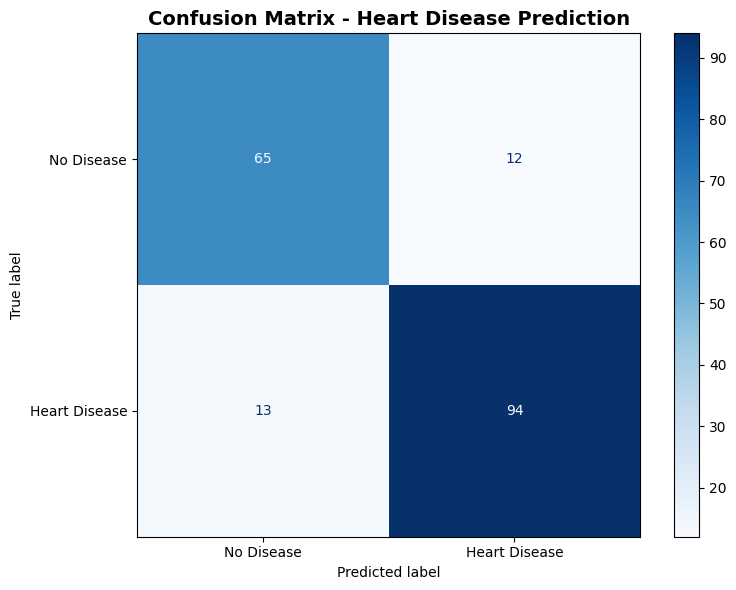

In [25]:
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Disease', 'Heart Disease'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Heart Disease Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **Learning Curve**

In [26]:
from sklearn.model_selection import learning_curve

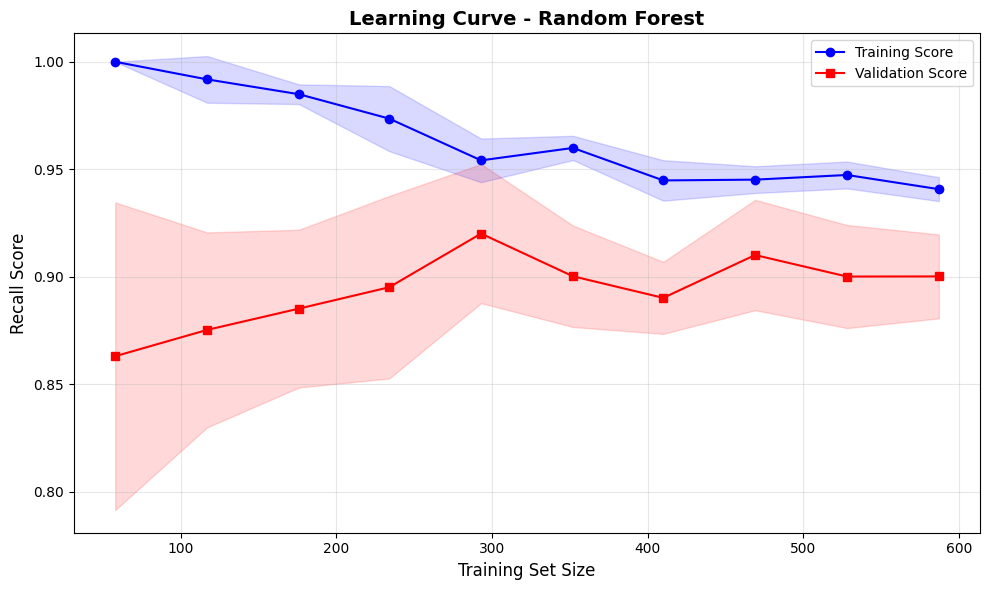

In [28]:
# Generate learning curve data
train_sizes, train_scores, val_scores = learning_curve(
    estimator=random_search_cv.best_estimator_,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

# Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, val_mean, label='Validation Score', color='red', marker='s')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Recall Score', fontsize=12)
plt.title('Learning Curve - Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()